In [1]:
# Let us first read the dataset and explore what it looks like
import pandas as pd

df = pd.read_csv('adult.csv')

df.head()

,age,workclass,fnlwgt,education,education.num,marital.status,occupation,relationship,race,sex,capital.gain,capital.loss,hours.per.week,native.country,income
0,90,?,77053,HS-grad,9,Widowed,?,Not-in-family,White,Female,0,4356,40,United-States,<=50K
1,82,Private,132870,HS-grad,9,Widowed,Exec-managerial,Not-in-family,White,Female,0,4356,18,United-States,<=50K
2,66,?,186061,Some-college,10,Widowed,?,Unmarried,Black,Female,0,4356,40,United-States,<=50K
3,54,Private,140359,7th-8th,4,Divorced,Machine-op-inspct,Unmarried,White,Female,0,3900,40,United-States,<=50K
4,41,Private,264663,Some-college,10,Separated,Prof-specialty,Own-child,White,Female,0,3900,40,United-States,<=50K


In [2]:
#Use describe to understand it better
df.describe()

,age,fnlwgt,education.num,capital.gain,capital.loss,hours.per.week
count,32561.000000,3.256100e+04,32561.000000,32561.000000,32561.000000,32561.000000
mean,38.581647,1.897784e+05,10.080679,1077.648844,87.303830,40.437456
std,13.640433,1.055500e+05,2.572720,7385.292085,402.960219,12.347429
min,17.000000,1.228500e+04,1.000000,0.000000,0.000000,1.000000
25%,28.000000,1.178270e+05,9.000000,0.000000,0.000000,40.000000
50%,37.000000,1.783560e+05,10.000000,0.000000,0.000000,40.000000
75%,48.000000,2.370510e+05,12.000000,0.000000,0.000000,45.000000
max,90.000000,1.484705e+06,16.000000,99999.000000,4356.000000,99.000000


In [3]:
#Info shows us the data types and memory usage
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 32561 entries, 0 to 32560
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   age             32561 non-null  int64
 1   workclass       32561 non-null  str  
 2   fnlwgt          32561 non-null  int64
 3   education       32561 non-null  str  
 4   education.num   32561 non-null  int64
 5   marital.status  32561 non-null  str  
 6   occupation      32561 non-null  str  
 7   relationship    32561 non-null  str  
 8   race            32561 non-null  str  
 9   sex             32561 non-null  str  
 10  capital.gain    32561 non-null  int64
 11  capital.loss    32561 non-null  int64
 12  hours.per.week  32561 non-null  int64
 13  native.country  32561 non-null  str  
 14  income          32561 non-null  str  
dtypes: int64(6), str(9)
memory usage: 3.7 MB


In [4]:
#Lets have a look at some features we can use for our ML model
df.columns

Index(['age', 'workclass', 'fnlwgt', 'education', 'education.num',
       'marital.status', 'occupation', 'relationship', 'race', 'sex',
       'capital.gain', 'capital.loss', 'hours.per.week', 'native.country',
       'income'],
      dtype='str')

In [5]:
# Missing values are stored as "?" in this dataset. Replace them, then drop those rows and any duplicates.
df = df.replace('?', pd.NA)
print("Missing values per column:\n", df.isna().sum())
print("Duplicate rows:", df.duplicated().sum())

df = df.dropna().drop_duplicates()
print("Shape after cleaning:", df.shape)

Missing values per column:
 age                  0
workclass         1836
fnlwgt               0
education            0
education.num        0
marital.status       0
occupation        1843
relationship         0
race                 0
sex                  0
capital.gain         0
capital.loss         0
hours.per.week       0
native.country     583
income               0
dtype: int64
Duplicate rows: 24
Shape after cleaning: (30139, 15)


In [6]:
# Filter: people who work more than 40 hours a week
overtime = df[df['hours.per.week'] > 40]
print("Rows working >40 hrs/week:", len(overtime))

# Group by education and see the share earning >50K
df['high_income'] = (df['income'] == '>50K').astype(int)
df.groupby('education')['high_income'].agg(['mean', 'count']).sort_values('mean', ascending=False)

Rows working >40 hrs/week: 9192


,mean,count
education,,
Prof-school,0.749077,542
Doctorate,0.746667,375
Masters,0.564576,1626
Bachelors,0.421658,5042
Assoc-voc,0.263198,1307
Assoc-acdm,0.253968,1008
Some-college,0.200180,6669
HS-grad,0.164328,9834
12th,0.076923,377


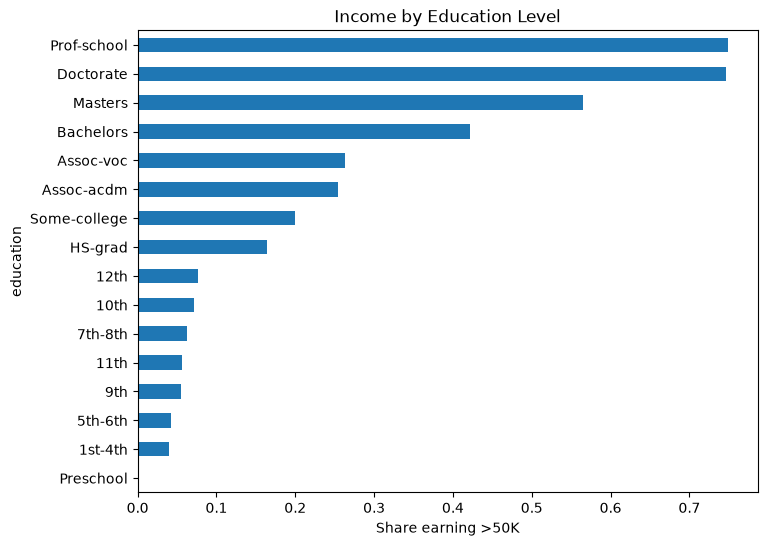

In [7]:
# Plot 1: Income by Education Level for >50k earners
import matplotlib.pyplot as plt

df.groupby('education')['high_income'].mean().sort_values().plot(kind='barh', figsize=(8, 6))
plt.xlabel('Share earning >50K')
plt.title('Income by Education Level')
plt.show()

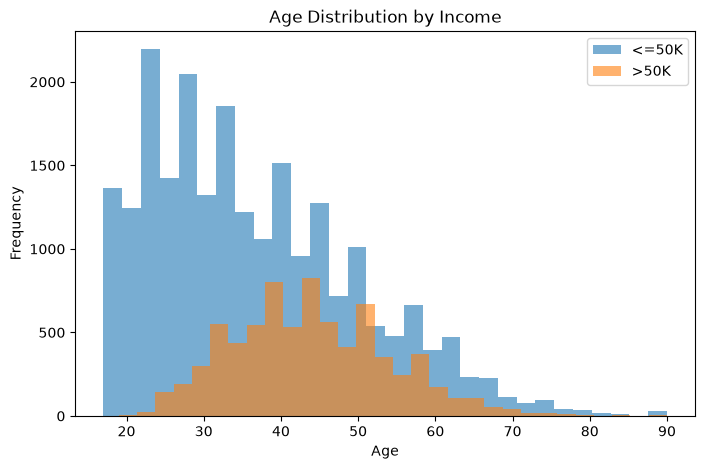

In [8]:
# Plot 2: Age distribution by income level, as we can see, very few people under 25 earn >50k. So age is a useful feature for our ML model.
df[df['income'] == '<=50K']['age'].plot(kind='hist', bins=30, alpha=0.6, label='<=50K', figsize=(8, 5))
df[df['income'] == '>50K']['age'].plot(kind='hist', bins=30, alpha=0.6, label='>50K')
plt.xlabel('Age')
plt.title('Age Distribution by Income')
plt.legend()
plt.show()

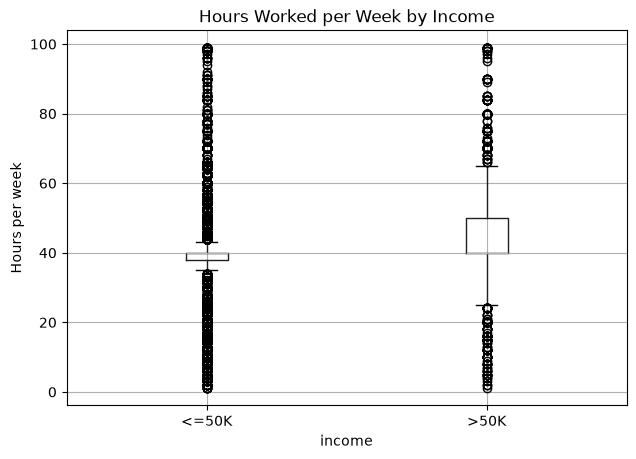

In [9]:
# Plot 3: Our final plot is a boxplot of hours worked per week by income level. Peoplee earning >50k work more hours per week on average.
df.boxplot(column='hours.per.week', by='income', figsize=(7, 5))
plt.ylabel('Hours per week')
plt.title('Hours Worked per Week by Income')
plt.suptitle('')
plt.show()

In [10]:
# Let us impliment a basic ML model using GradientBostingClassifier to predict high income based on the features in the dataset. I will use one-hot encoding for categorical variables.
from sklearn.model_selection import train_test_split
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import accuracy_score

# Inputs: every column except the target (using all columns as features). Text columns are one-hot encoded so the model can use them.
X = pd.get_dummies(df.drop(columns=['income', 'high_income']))
y = df['high_income']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = GradientBoostingClassifier(random_state=42)
model.fit(X_train, y_train)

# Evaluate the model on the test set and printing out the accuracy
print("Accuracy:", round(accuracy_score(y_test, model.predict(X_test)), 4))

Accuracy: 0.865


In [11]:
# Which features mattered most to the model?
importances = pd.Series(model.feature_importances_, index=X.columns).sort_values(ascending=False)

print(importances.head(10))


marital.status_Married-civ-spouse    0.385910
education.num                        0.200594
capital.gain                         0.193301
capital.loss                         0.060102
age                                  0.059645
hours.per.week                       0.035692
occupation_Exec-managerial           0.015982
occupation_Other-service             0.006575
occupation_Farming-fishing           0.006466
occupation_Prof-specialty            0.004532
dtype: float64


In [12]:
# In this cell, I wil compare polars and pandas to compare performance. I am going to do the exact same analysis that I did in Pandas with Polars to compare the performance.
import polars as pl
import time

# I will start with Pandas here and count how long it takes to do the operations we did in this notebook using the time module.
start = time.perf_counter()
pdf = pd.read_csv('adult.csv')
pdf = pdf.replace('?', pd.NA).dropna().drop_duplicates()
pd_result = (pdf[pdf['hours.per.week'] > 40]
             .groupby('education')['age'].mean())
pandas_time = time.perf_counter() - start

# Let us now do the exact same operations with Polars and time it as well to see if its faster.
start = time.perf_counter()
pldf = pl.read_csv('adult.csv', null_values='?').drop_nulls().unique()
pl_result = (pldf.filter(pl.col('hours.per.week') > 40)
             .group_by('education').agg(pl.col('age').mean()))
polars_time = time.perf_counter() - start

# Outputting the results of the timing. Clearly Polars is fater than Pandas for this dataset of 32k rows and these specific operations.
print(f"Pandas: {pandas_time:.4f} s")
print(f"Polars: {polars_time:.4f} s")
print(f"Polars is {pandas_time / polars_time:.1f}x faster")

Pandas: 0.0766 s
Polars: 0.0138 s
Polars is 5.5x faster
